In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocess import (
    load_data,
    clean_data,
    handle_missing_values
)

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

In [2]:
df = load_data("../data/customer_churn_1M.csv")

df = clean_data(df)

df = handle_missing_values(df)

print(df.shape)

(1000000, 31)


In [3]:
target = "churn"

categorical_cols = (
    df.select_dtypes(include=["object"])
      .columns
      .tolist()
)

numerical_cols = (
    df.select_dtypes(
        include=["int64", "float64"]
    )
    .columns
    .tolist()
)

numerical_cols.remove(target)

In [4]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [7]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [8]:
xgb_model.fit(X_train, y_train)

print("XGBoost Training Complete")

XGBoost Training Complete


In [9]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [10]:
print("classification report:")
print(classification_report(y_test, xgb_pred))

classification report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    180155
           1       0.51      0.00      0.01     19845

    accuracy                           0.90    200000
   macro avg       0.70      0.50      0.48    200000
weighted avg       0.86      0.90      0.85    200000



In [11]:
print("confusion matrix:")
print(confusion_matrix(y_test, xgb_pred))


confusion matrix:
[[180059     96]
 [ 19747     98]]


In [12]:
auc = roc_auc_score(y_test, xgb_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6845861927118146


In [13]:
print(y_train.value_counts())

churn
0    720618
1     79382
Name: count, dtype: int64


In [14]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

print(neg / pos)

9.077851402081077


In [16]:
import numpy as np

print("Min probability:", np.min(xgb_prob))
print("Max probability:", np.max(xgb_prob))
print("Mean probability:", np.mean(xgb_prob))
print("Number of positive predictions:", (xgb_prob > 0.5).sum())
auc = roc_auc_score(y_test, xgb_prob)

print("ROC-AUC:", auc)

Min probability: 0.010382889
Max probability: 0.84611547
Mean probability: 0.09945236
Number of positive predictions: 194
ROC-AUC: 0.6845861927118146


In [17]:
for threshold in [0.5, 0.3, 0.2, 0.15, 0.1]:
    
    pred = (xgb_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print("Classification Report:")
    print(
        classification_report(
            y_test,
            pred,
            output_dict=False
        )
    )


Threshold: 0.5
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    180155
           1       0.51      0.00      0.01     19845

    accuracy                           0.90    200000
   macro avg       0.70      0.50      0.48    200000
weighted avg       0.86      0.90      0.85    200000


Threshold: 0.3
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95    180155
           1       0.37      0.06      0.10     19845

    accuracy                           0.90    200000
   macro avg       0.64      0.52      0.52    200000
weighted avg       0.85      0.90      0.86    200000


Threshold: 0.2
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93    180155
           1       0.26      0.20      0.23     19845

    accuracy                           0.87    200000
   macro av

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.5, 0.3, 0.2, 0.15, 0.1]:

    pred = (xgb_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(
        f"Threshold={threshold} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.5 | Precision=0.505 | Recall=0.005 | F1=0.010
Threshold=0.3 | Precision=0.369 | Recall=0.060 | F1=0.103
Threshold=0.2 | Precision=0.264 | Recall=0.197 | F1=0.225
Threshold=0.15 | Precision=0.212 | Recall=0.361 | F1=0.267
Threshold=0.1 | Precision=0.160 | Recall=0.631 | F1=0.255


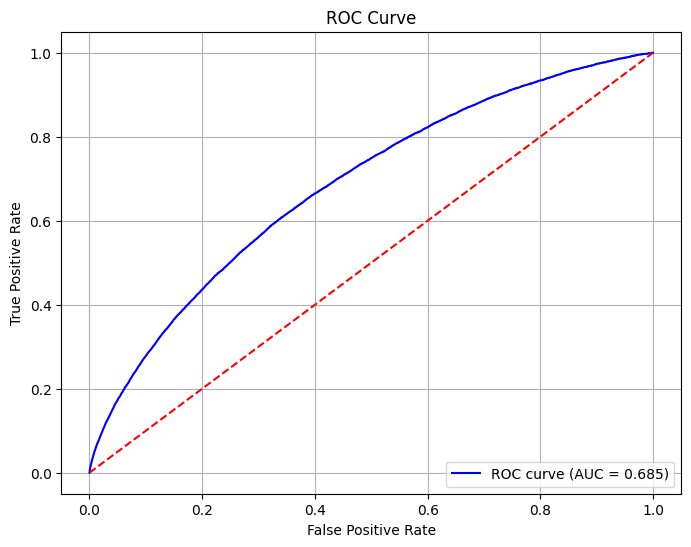

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [21]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']

In [24]:
import joblib

xgb_model = joblib.load(
    "../models/xgboost.pkl"
)
print("xgb model feature importances:", xgb_model.feature_importances_)

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'